<a href="https://colab.research.google.com/github/SamirGoo/NewAthena-Project/blob/main/NewAthena_HorizonPlotting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install lalsuite

In [2]:
#!pip install bilby

In [3]:
#!pip install git+https://github.com/janosch314/GWFish.git lalsuite corner

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import bilby as bb
import GWFish
from GWFish.modules.detection import Network, Detector
from GWFish.modules.horizon import horizon
from GWFish.modules.fishermatrix import compute_network_errors, compute_detector_fisher
import GWFish.modules as gwf_mods
import pathlib
import os

from astropy.cosmology import Planck18
from astropy.cosmology import z_at_value
import astropy.units as u

import utils

/usr/local/lib/python3.12/dist-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [5]:
base_dir = os.getcwd()

# Detectors are one CE at LLO location, one CE at Gingin (Australia), ET in Sardinia
detectors = ['CE1', 'CE2', 'ET']
ls = [':', '-.', '--']

#new max horizon: dL=608465.4969298993, z=48.99134890039851 for ra=4.310664640963899, dec=-0.7176488681791958

params = {
    'total_mass': 900,
    'mass_ratio': 0.9,
    'theta_jn': 0.0,
    'phase': 2.8,
    'geocent_time': 0.00475200053340101,
    'ra': 4.310664640963899,
    'dec': -0.7176488681791958,
    'psi': 0.2,}


network = gwf_mods.detection.Network(detector_ids=detectors,
                                     detection_SNR=(0., 12.),
                                     config=pathlib.Path('/content/detectors.yaml'))
dets = {}
for det_name in detectors:
    dets[det_name] = Detector(det_name,
                              config=pathlib.Path('/content/detectors.yaml'))

#total_mass_range = np.logspace(1.5, 4.4, 200)
total_mass_range = np.logspace(1.5, 4.4, 50)
hzn_store = {'nwk': [], 'CE1': [], 'CE2': [], 'ET': [], "NA": []}

for tmass in total_mass_range:
    params['total_mass'] = tmass
    params['mass_1'], params['mass_2'] = bb.gw.conversion.total_mass_and_mass_ratio_to_component_masses(
                                             mass_ratio=params['mass_ratio'], total_mass=params['total_mass'])
    hzn, rz = horizon(params, network, waveform_model='IMRPhenomXPHM', target_SNR=10.0)
    print("tmass: {}, m1: {}, m2: {},  horizon dL: {}, z: {}".format(tmass, params['mass_1'], params['mass_2'], hzn, rz))
    hzn_store['nwk'].append(rz)
    for det_name in detectors:
        try:
            hzni, rzi = horizon(params, dets[det_name], waveform_model='IMRPhenomXPHM', target_SNR=10.0)
            hzn_store[det_name].append(rzi)
        except:
            print(det_name, "dropped")
    NA_dist = utils.max_distance_NewAthena(tmass, fj=0.7**2)
    rz_na = z_at_value(Planck18.luminosity_distance, NA_dist * u.Mpc)
    hzn_store["NA"].append(rz_na)
    print("NA redshift: {}".format(rz_na))

<>:60: SyntaxWarning: invalid escape sequence '\o'
<>:60: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_5948/89860684.py:60: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("total mass [M$_\odot$]")


tmass: 31.622776601683793, m1: 16.643566632465156, m2: 14.97920996921864,  horizon dL: 118920.13548722038, z: 11.06946473408068
NA redshift: 0.15759106051394836 redshift
tmass: 36.239623200020866, m1: 19.073485894747826, m2: 17.166137305273043,  horizon dL: 132345.44558152245, z: 12.171294627201144
NA redshift: 0.17835566558178376 redshift
tmass: 41.53051789922715, m1: 21.858167315382712, m2: 19.67235058384444,  horizon dL: 147199.99452916067, z: 13.380931106143734
NA redshift: 0.20163532785817154 redshift
tmass: 47.59387004269498, m1: 25.04940528562894, m2: 22.544464757066045,  horizon dL: 163622.3071148582, z: 14.708300749683767
NA redshift: 0.22769797137140216 redshift
tmass: 54.54245649277324, m1: 28.706556048828023, m2: 25.83590044394522,  horizon dL: 181764.3101636617, z: 16.164284872857138
NA redshift: 0.25683727739853024 redshift
tmass: 62.50551925273973, m1: 32.897641711968284, m2: 29.607877540771455,  horizon dL: 201796.69315460682, z: 17.761133113894342
NA redshift: 0.289376

/usr/local/lib/python3.12/dist-packages/GWFish/modules/horizon.py:129: UserWarning: The source is completely out of band
  warnings.warn('The source is completely out of band')
/usr/local/lib/python3.12/dist-packages/GWFish/modules/horizon.py:129: UserWarning: The source is completely out of band
  warnings.warn('The source is completely out of band')


NA redshift: 26.44482210290332 redshift
tmass: 14563.484775012445, m1: 7664.991986848655, m2: 6898.49278816379,  horizon dL: 134.88350395826654, z: 0.029769758792038865


/usr/local/lib/python3.12/dist-packages/GWFish/modules/horizon.py:129: UserWarning: The source is completely out of band
  warnings.warn('The source is completely out of band')
/usr/local/lib/python3.12/dist-packages/GWFish/modules/horizon.py:129: UserWarning: The source is completely out of band
  warnings.warn('The source is completely out of band')


...

NA redshift: 38.55422109861208 redshift
tmass: 21918.777420506536, m1: 11536.19864237186, m2: 10382.578778134675,  horizon dL: 1.2361375439707558, z: 0.0002789235878904548


/usr/local/lib/python3.12/dist-packages/GWFish/modules/horizon.py:129: UserWarning: The source is completely out of band
  warnings.warn('The source is completely out of band')
/usr/local/lib/python3.12/dist-packages/GWFish/modules/horizon.py:129: UserWarning: The source is completely out of band
  warnings.warn('The source is completely out of band')


NA redshift: 43.761999395215994 redshift
tmass: 25118.864315095823, m1: 13220.454902682013, m2: 11898.409412413812,  horizon dL: 0.1597918928324062, z: 3.6062350129781614e-05


/usr/local/lib/python3.12/dist-packages/GWFish/modules/horizon.py:129: UserWarning: The source is completely out of band
  warnings.warn('The source is completely out of band')
/usr/local/lib/python3.12/dist-packages/GWFish/modules/horizon.py:129: UserWarning: The source is completely out of band
  warnings.warn('The source is completely out of band')


NA redshift: 49.69753934638739 redshift


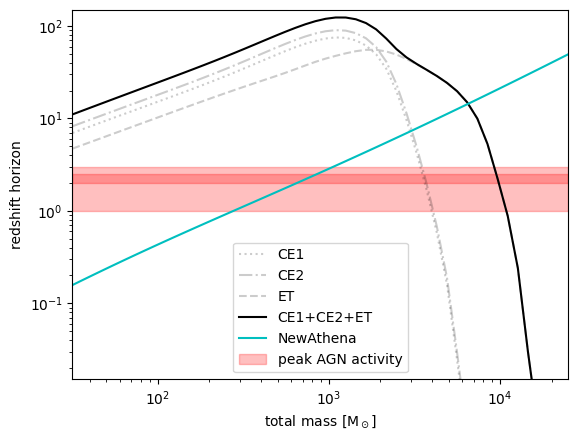

In [8]:
fig = plt.figure()
for i, det_name in enumerate(detectors):
    plt.loglog(total_mass_range[0:len(hzn_store[det_name])], hzn_store[det_name], label=det_name, color='k', ls=ls[i], alpha=0.2)
plt.loglog(total_mass_range, hzn_store['nwk'], label='CE1+CE2+ET', color='k')
plt.loglog(total_mass_range, hzn_store['NA'], label='NewAthena', color='c')
plt.ylim(1.5e-2, 1.5e2)
plt.xlim(min(total_mass_range), max(total_mass_range))
plt.fill_between(total_mass_range, y1=1, y2=3, color='r', alpha=0.25)
plt.fill_between(total_mass_range, y1=2, y2=2.5, color='r', alpha=0.25, label='peak AGN activity')
plt.legend()
plt.xlabel(r"total mass [M$_\odot$]")
plt.ylabel("redshift horizon")
plt.savefig("horizon_3G_network.png")
plt.show()